# Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_percentage_error

from prophet import Prophet
import lightgbm as lgb

from neuralforecast import NeuralForecast
from neuralforecast.models import TFT
from neuralforecast.models import NHITS
from neuralforecast.losses.pytorch import MAE

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

results = {}

# Data Loading

In [2]:
train = pd.read_csv('../data/raw/train.csv', parse_dates=['Date'])
store = pd.read_csv('../data/raw/store.csv')

df = train.merge(store, on='Store', how='left')
df = df[(df['Open'] == 1) & (df['Sales'] > 0)].copy()

# Store 1 only
store_id = 1
df_store = df[df['Store'] == store_id].sort_values('Date').copy()

# Train / test split
cutoff = df_store['Date'].max() - pd.Timedelta(weeks=6)
train_s = df_store[df_store['Date'] <= cutoff].copy()
test_s  = df_store[df_store['Date'] > cutoff].copy()

print(f"Train: {len(train_s)} days | Test: {len(test_s)} days")

Train: 745 days | Test: 36 days


# Prophet

## Data Preparation for Prophet

- Prophet expects two columns: ds (date) and y (value)
- Training is performed on log(sales) as decided after EDA (notebook 1)

In [3]:
prophet_train = train_s[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})
prophet_train['y'] = np.log1p(prophet_train['y'])

prophet_test = test_s[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})

print("Prophet expected format:")
prophet_train.head(5)

Prophet expected format:


,ds,y
1014980,2013-01-02,8.618124
1013865,2013-01-03,8.372861
1012750,2013-01-04,8.408940
1011635,2013-01-05,8.516793
1009405,2013-01-07,8.878637


## Prophet Training

In [4]:
model_prophet = Prophet(
    seasonality_mode='multiplicative',  # good for log-normal data
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
)

# Add promo as external regressor (insight from EDA in notebook 1)
prophet_train['promo'] = train_s['Promo'].values
model_prophet.add_regressor('promo')

model_prophet.fit(prophet_train)
print("Prophet trained ✓")

16:18:13 - cmdstanpy - INFO - Chain [1] start processing
16:18:13 - cmdstanpy - INFO - Chain [1] done processing


Prophet trained ✓


## Prophet Predictions

In [5]:
# Test data preparation
future = prophet_test[['ds']].copy()
future['promo'] = test_s['Promo'].values

# Predictions
forecast = model_prophet.predict(future)

# Use exp fonction to transform log(sales) back to sales
y_pred_prophet = np.expm1(forecast['yhat'].values)
y_true = test_s['Sales'].values

mape_prophet = mean_absolute_percentage_error(y_true, y_pred_prophet) * 100
results['Prophet'] = round(mape_prophet, 2)

print(f"Prophet MAPE : {mape_prophet:.1f}%")
print(f"Improvement vs baseline : {17.3 - mape_prophet:.1f} points")

Prophet MAPE : 7.3%
Improvement vs baseline : 10.0 points


## Prediction Visualization

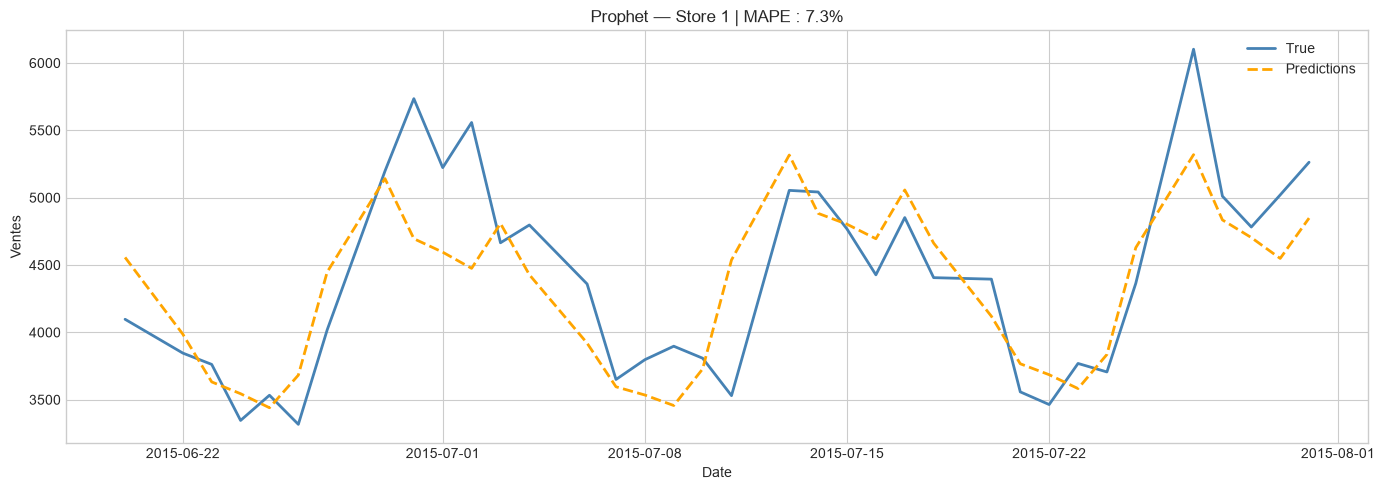

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test_s['Date'].values, y_true, label='True', color='steelblue', linewidth=2)
ax.plot(test_s['Date'].values, y_pred_prophet, label='Predictions', 
        color='orange', linewidth=2, linestyle='--')

ax.set_title(f'Prophet — Store {store_id} | MAPE : {mape_prophet:.1f}%')
ax.set_xlabel('Date')
ax.set_ylabel('Ventes')
ax.legend()
plt.tight_layout()
plt.show()

# LightGBM

## Feature Engineering for LightGBM

In [7]:
def make_features(df):
    df = df.copy()

    # Time-related features
    df['year'] = df['Date'].dt.year
    df['month'] = df['Date'].dt.month
    df['day'] = df['Date'].dt.day
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['quarter'] = df['Date'].dt.quarter
    df['is_weekend'] = (df['Date'].dt.dayofweek >= 5).astype(int)
    df['is_month_start'] = df['Date'].dt.is_month_start.astype(int)
    df['is_month_end'] = df['Date'].dt.is_month_end.astype(int)

    # Lag
    df['lag_7'] = df['Sales'].shift(7)
    df['lag_14'] = df['Sales'].shift(14)
    df['lag_28'] = df['Sales'].shift(28)

    # Moving averages
    df['rolling_mean_7'] = df['Sales'].shift(1).rolling(7).mean()
    df['rolling_mean_28'] = df['Sales'].shift(1).rolling(28).mean()
    df['rolling_std_7'] = df['Sales'].shift(1).rolling(7).std()

    # Sales-to-average ratio
    df['sales_vs_rolling'] = df['Sales'] / (df['rolling_mean_7'] + 1)

    # Store
    df['Promo'] = df['Promo'].astype(int)
    df['StateHoliday'] = df['StateHoliday'].map({'0': 0, 'a': 1, 'b': 2, 'c': 3}).fillna(0)
    df['StoreType'] = df['StoreType'].map({'a': 0, 'b': 1, 'c': 2, 'd': 3})
    df['Assortment'] = df['Assortment'].map({'a': 0, 'b': 1, 'c': 2})

    return df

print(f"Shape before feature engineering : {df_store.shape}")
df_feat = make_features(df_store)

# Remove columns with mostly NaN values
df_feat.drop(['Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'], axis=1, inplace=True)

# Remove NaN rows (created by adding the lags)
df_feat = df_feat.dropna()

print(f"Shape after feature engineering : {df_feat.shape}")
print(f"Features : {df_feat.shape[1]} columns")
df_feat.head(5)


Shape before feature engineering : (781, 18)
Shape after feature engineering : (753, 31)
Features : 31 columns


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,year,month,day,dayofweek,weekofyear,quarter,is_weekend,is_month_start,is_month_end,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_28,rolling_std_7,sales_vs_rolling
978185,1,1,2013-02-04,7032,762,1,1,0.0,0,2,0,1270.0,9.0,2008.0,0,2013,2,4,0,6,1,0,0,0,5598.0,4127.0,5530.0,4898.714286,5001.214286,855.366727,1.435186
977070,1,2,2013-02-05,6049,678,1,1,0.0,0,2,0,1270.0,9.0,2008.0,0,2013,2,5,1,6,1,0,0,0,4055.0,5182.0,4327.0,5103.571429,5054.857143,1166.051436,1.185016
975955,1,3,2013-02-06,6140,693,1,1,0.0,0,2,0,1270.0,9.0,2008.0,0,2013,2,6,2,6,1,0,0,0,3725.0,5394.0,4486.0,5388.428571,5116.357143,1109.382990,1.139267
974840,1,4,2013-02-07,5499,675,1,1,0.0,0,2,0,1270.0,9.0,2008.0,0,2013,2,7,3,6,1,0,0,0,4601.0,5720.0,4997.0,5733.428571,5175.428571,851.378658,0.958945
973725,1,5,2013-02-08,5681,630,1,1,0.0,0,2,0,1270.0,9.0,2008.0,0,2013,2,8,4,6,1,0,0,0,4709.0,5578.0,7176.0,5861.714286,5193.357143,707.864797,0.969005


## Train/test Split for LightGBM

In [8]:
FEATURES = [
    # Temporelles
    'year', 'month', 'day', 'dayofweek', 'weekofyear', 'quarter',
    'is_weekend', 'is_month_start', 'is_month_end',
    # Lags
    'lag_7', 'lag_14', 'lag_28',
    # Moyennes mobiles
    'rolling_mean_7', 'rolling_mean_28', 'rolling_std_7', 'sales_vs_rolling',
    # Store
    'Promo', 'StateHoliday', 'StoreType', 'Assortment',
    'CompetitionDistance',
]

TARGET = 'Sales'

# Same cutoff date
cutoff = df_feat['Date'].max() - pd.Timedelta(weeks=6)
train_lgb = df_feat[df_feat['Date'] <= cutoff].copy()
test_lgb  = df_feat[df_feat['Date'] > cutoff].copy()

X_train = train_lgb[FEATURES]
y_train = np.log1p(train_lgb[TARGET])  # log transform

X_test  = test_lgb[FEATURES]
y_test  = test_lgb[TARGET].values

print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"Features selected : {len(FEATURES)}")

Train : (717, 21) | Test : (36, 21)
Features selected : 21


## Training LightGBM

In [9]:
model_lgb = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_test, np.log1p(y_test))],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)

print(f"Optimal number of estimators : {model_lgb.best_iteration_}")

[100]	valid_0's l2: 0.000431855
[200]	valid_0's l2: 0.000389628
Optimal number of estimators : 197


## Predictions & Metrics with LightGBM

LightGBM MAPE : 1.7%
Prophet MAPE  : 7.33%
Baseline MAPE : 17.3%


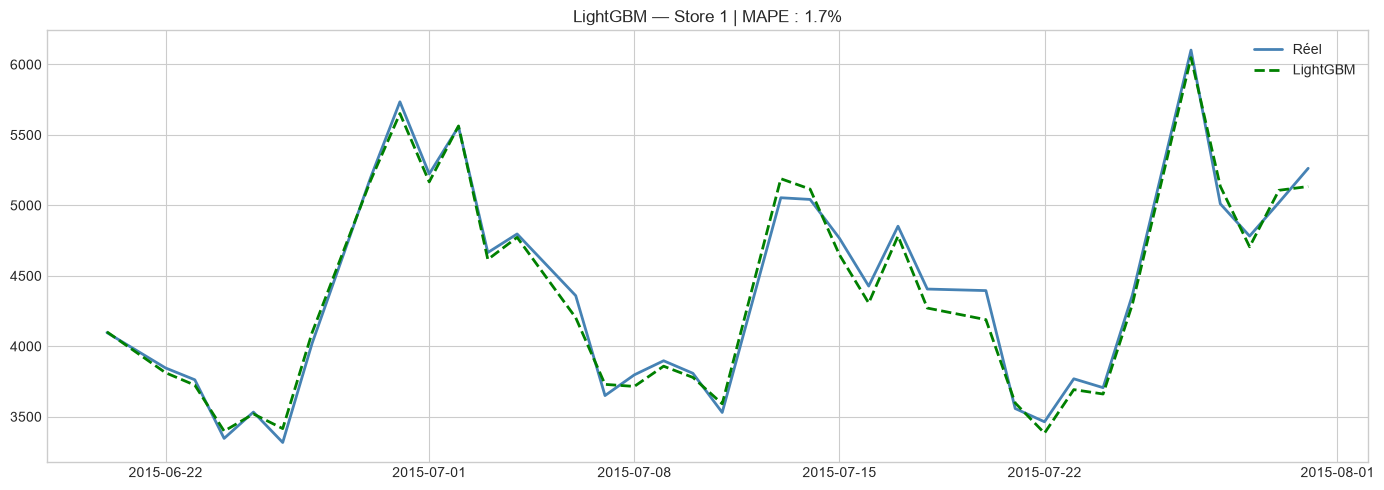

In [10]:
y_pred_lgb = np.expm1(model_lgb.predict(X_test))

mape_lgb = mean_absolute_percentage_error(y_test, y_pred_lgb) * 100
results['LightGBM'] = round(mape_lgb, 2)

print(f"LightGBM MAPE : {mape_lgb:.1f}%")
print(f"Prophet MAPE  : {results['Prophet']}%")
print(f"Baseline MAPE : 17.3%")

# Visualisation
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_lgb['Date'].values, y_test, 
        label='Réel', color='steelblue', linewidth=2)
ax.plot(test_lgb['Date'].values, y_pred_lgb, 
        label='LightGBM', color='green', linewidth=2, linestyle='--')
ax.set_title(f'LightGBM — Store {store_id} | MAPE : {mape_lgb:.1f}%')
ax.legend()
plt.tight_layout()
plt.show()

## Feature Importance

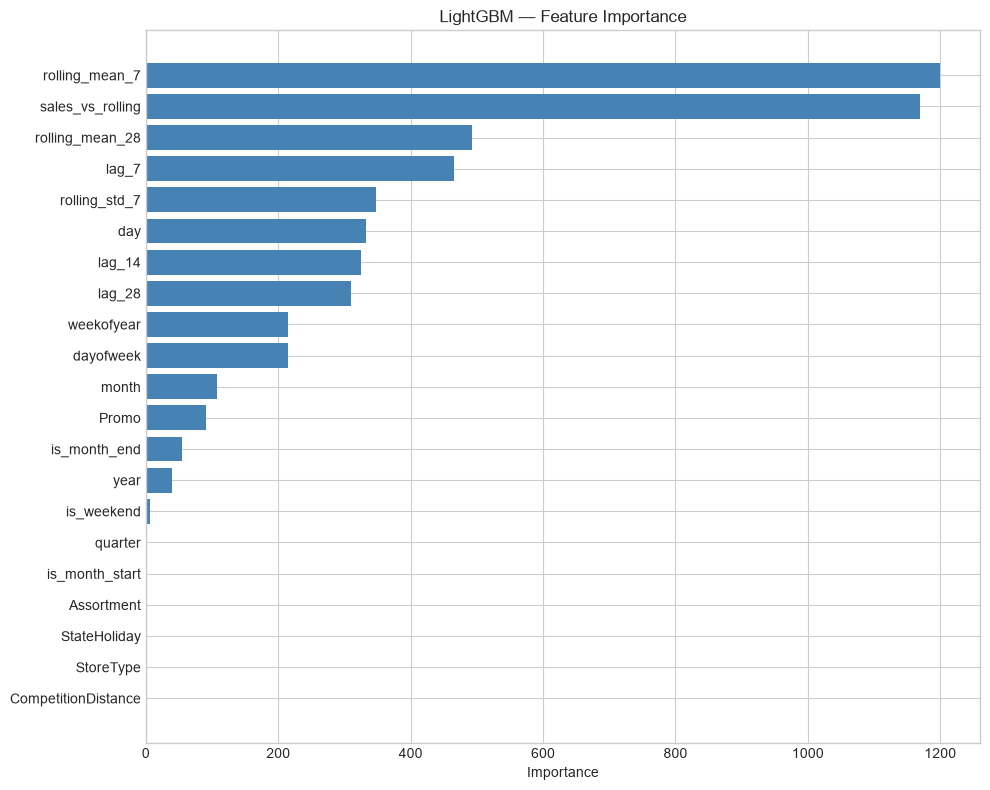


Top 5 features :
         feature  importance
   rolling_std_7         348
           lag_7         466
 rolling_mean_28         492
sales_vs_rolling        1169
  rolling_mean_7        1200


In [11]:
feat_imp = pd.DataFrame({
    'feature': FEATURES,
    'importance': model_lgb.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp['feature'], feat_imp['importance'], color='steelblue')
ax.set_title('LightGBM — Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 5 features :")
print(feat_imp.tail(5)[['feature', 'importance']].to_string(index=False))

## LightGBM Results

- MAPE : 1.7% (vs 7.3% Prophet, vs 17.3% baseline)
- SC features (lags, rolling means) dominate the other ones
- `sales_vs_rolling`,  demand / recent trend ratio, is an integrated anomaly detection signal
- `Promo` does not come up as a top feature but is surely encoding into the moving averages. Importance is real as demonstrated during EDA (+38.8% lift)

**Décision** : LightGBM is the best model for this store. TFT to be evaluated for multi-store generalization.

# NeuralForecast

## Data Preparation for NeuralForecast

3 columns are expected:
- series ID (unique_id)
- date (ds)
- target (y)

In [12]:
df_nf = df_store[['Date', 'Sales', 'Promo']].rename(columns={
    'Date': 'ds',
    'Sales': 'y'
})
df_nf['unique_id'] = f'store_{store_id}'
df_nf['y'] = np.log1p(df_nf['y'])  # log transform

# Exogenous variables are called "futr_exog_list" by NeuralForecat
df_nf = df_nf[['unique_id', 'ds', 'y', 'Promo']]

print(f"Shape : {df_nf.shape}")
df_nf.tail(3)


Shape : (781, 4)


,unique_id,ds,y,Promo
2230,store_1,2015-07-29,8.472823,1
1115,store_1,2015-07-30,8.521384,1
0,store_1,2015-07-31,8.568646,1


## Train/test split for NeuralForecast

In [13]:
horizon = len(test_s)
print(f"Horizon : {horizon} days")

df_train_nf = df_nf[df_nf['ds'] <= cutoff].copy()
df_test_nf  = df_nf[df_nf['ds'] > cutoff].copy()

print(f"Train NF : {len(df_train_nf)} | Test NF : {len(df_test_nf)}")

Horizon : 36 days
Train NF : 745 | Test NF : 36


## Training NeuralForecast

In [ ]:

import os
os.environ["TUNE_DISABLE_AUTO_INIT"] = "1"
os.environ["RAY_DISABLE_IMPORT_WARNING"] = "1"

# Forcer NeuralForecast à ne pas utiliser Ray
import ray
if ray.is_initialized():
    ray.shutdown()

models = [
    TFT(
        h=horizon,
        input_size=horizon,        # minimal — même valeur que h
        hidden_size=32,
        n_head=2,
        learning_rate=1e-3,
        max_steps=200,
        futr_exog_list=['Promo'],
        loss=MAE(),
        random_seed=42,
        enable_progress_bar=True,
    )
]

nf = NeuralForecast(models=models, freq='D')

nf.fit(df_train_nf)
print("TFT trained")

Seed set to 42


In [ ]:

import os
os.environ["TUNE_DISABLE_AUTO_INIT"] = "1"
os.environ["RAY_DISABLE_IMPORT_WARNING"] = "1"

# Forcer NeuralForecast à ne pas utiliser Ray
import ray
if ray.is_initialized():
    ray.shutdown()

models = [
    NHITS(
        h=horizon,
        input_size=horizon,
        max_steps=10,
        loss=MAE(),
        random_seed=42,
        enable_progress_bar=True,
    )
]

nf = NeuralForecast(models=models, freq='D')
nf.fit(df_train_nf)
print("NHITS entraîné ✓")

Seed set to 42


## TFT Predictions

In [ ]:
futr_df = df_test_nf[['unique_id', 'ds', 'Promo']].copy()

preds = nf.predict(futr_df=futr_df)

# from log(sales) back to sales
y_pred_tft = np.expm1(preds['TFT'].values)
y_true_tft = test_s['Sales'].values

mape_tft = mean_absolute_percentage_error(y_true_tft, y_pred_tft) * 100
results['TFT'] = round(mape_tft, 2)

print(f"TFT MAPE     : {mape_tft:.1f}%")
print(f"LightGBM MAPE: {results['LightGBM']}%")
print(f"Prophet MAPE : {results['Prophet']}%")
print(f"Baseline MAPE: 17.3%")

## TFT Result Visualization

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test_s['Date'].values, y_true_tft,
        label='Réel', color='steelblue', linewidth=2)
ax.plot(test_s['Date'].values, y_pred_tft,
        label='TFT', color='purple', linewidth=2, linestyle='--')

ax.set_title(f'TFT — Store {store_id} | MAPE : {mape_tft:.1f}%')
ax.legend()
plt.tight_layout()
plt.show()

## Result Comparison

In [ ]:
results['Baseline'] = 17.3

df_results = pd.DataFrame([
    {'Modèle': k, 'MAPE (%)': v, 'vs Baseline (pts)': round(17.3 - v, 1)}
    for k, v in results.items()
]).sort_values('MAPE (%)')

print("=" * 45)
print("FINAL BENCHMARK — Store", store_id)
print("=" * 45)
print(df_results.to_string(index=False))
print("=" * 45)

# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['green' if v == df_results['MAPE (%)'].min() 
          else 'steelblue' for v in df_results['MAPE (%)']]
ax.barh(df_results['Model'], df_results['MAPE (%)'], color=colors)
ax.axvline(x=17.3, color='red', linestyle='--', label='Baseline')
ax.set_title('Model comparison — MAPE (%)')
ax.set_xlabel('MAPE (%) — lower = better')
ax.legend()
plt.tight_layout()
plt.show()
